Cell 1 – Install Polars (Run once)

In [1]:
!pip install polars pyarrow matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/837.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ------------ --------------------------- 262.1/837.6 kB ? eta -:--:--
   ----------------------- -------------- 524.3/837.6 kB 214.0 kB/s eta 0:00:02
   ----------------------- -------------- 524.3/837.6 kB 214.0 kB/s eta 0:00:02
   ---------------------------------------- 837.6/837.6 kB 330.6 kB/s  0:00:02
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ------------------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Cell 2 – Import Libraries

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("Polars Version:", pl.__version__)

Polars Version: 1.42.1


Cell 3 – Load Dataset

In [4]:
import polars as pl

df = pl.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1",
    infer_schema_length=10000,
    ignore_errors=True
)

df.head()

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-BO-10001798""","""Furniture""","""Bookcases""","""Bush Somerset Collection Bookc…",261.96,2,0.0,41.9136
2,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-CH-10000454""","""Furniture""","""Chairs""","""Hon Deluxe Fabric Upholstered …",731.94,3,0.0,219.582
3,"""CA-2016-138688""","""6/12/2016""","""6/16/2016""","""Second Class""","""DV-13045""","""Darrin Van Huff""","""Corporate""","""United States""","""Los Angeles""","""California""",90036,"""West""","""OFF-LA-10000240""","""Office Supplies""","""Labels""","""Self-Adhesive Address Labels f…",14.62,2,0.0,6.8714
4,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""FUR-TA-10000577""","""Furniture""","""Tables""","""Bretford CR4500 Series Slim Re…",957.5775,5,0.45,-383.031
5,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""OFF-ST-10000760""","""Office Supplies""","""Storage""","""Eldon Fold 'N Roll Cart System""",22.368,2,0.2,2.5164


Cell 4 – Dataset Shape

In [5]:
print("Rows :", df.height)
print("Columns :", df.width)

Rows : 9994
Columns : 21


Cell 5 – Column Names

In [6]:
print(df.columns)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


Cell 6 – Data Types

In [7]:
print(df.dtypes)

[Int64, String, String, String, String, String, String, String, String, String, String, Int64, String, String, String, String, String, Float64, Int64, Float64, Float64]


Cell 7 – Dataset Preview

In [8]:
df

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-BO-10001798""","""Furniture""","""Bookcases""","""Bush Somerset Collection Bookc…",261.96,2,0.0,41.9136
2,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-CH-10000454""","""Furniture""","""Chairs""","""Hon Deluxe Fabric Upholstered …",731.94,3,0.0,219.582
3,"""CA-2016-138688""","""6/12/2016""","""6/16/2016""","""Second Class""","""DV-13045""","""Darrin Van Huff""","""Corporate""","""United States""","""Los Angeles""","""California""",90036,"""West""","""OFF-LA-10000240""","""Office Supplies""","""Labels""","""Self-Adhesive Address Labels f…",14.62,2,0.0,6.8714
4,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""FUR-TA-10000577""","""Furniture""","""Tables""","""Bretford CR4500 Series Slim Re…",957.5775,5,0.45,-383.031
5,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""OFF-ST-10000760""","""Office Supplies""","""Storage""","""Eldon Fold 'N Roll Cart System""",22.368,2,0.2,2.5164
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9990,"""CA-2014-110422""","""1/21/2014""","""1/23/2014""","""Second Class""","""TB-21400""","""Tom Boeckenhauer""","""Consumer""","""United States""","""Miami""","""Florida""",33180,"""South""","""FUR-FU-10001889""","""Furniture""","""Furnishings""","""Ultra Door Pull Handle""",25.248,3,0.2,4.1028
9991,"""CA-2017-121258""","""2/26/2017""","""3/3/2017""","""Standard Class""","""DB-13060""","""Dave Brooks""","""Consumer""","""United States""","""Costa Mesa""","""California""",92627,"""West""","""FUR-FU-10000747""","""Furniture""","""Furnishings""","""Tenex B1-RE Series Chair Mats …",91.96,2,0.0,15.6332
9992,"""CA-2017-121258""","""2/26/2017""","""3/3/2017""","""Standard Class""","""DB-13060""","""Dave Brooks""","""Consumer""","""United States""","""Costa Mesa""","""California""",92627,"""West""","""TEC-PH-10003645""","""Technology""","""Phones""","""Aastra 57i VoIP phone""",258.576,2,0.2,19.3932


Cell 8 – First 10 Rows

In [9]:
df.head(10)

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-BO-10001798""","""Furniture""","""Bookcases""","""Bush Somerset Collection Bookc…",261.96,2,0.0,41.9136
2,"""CA-2016-152156""","""11/8/2016""","""11/11/2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-CH-10000454""","""Furniture""","""Chairs""","""Hon Deluxe Fabric Upholstered …",731.94,3,0.0,219.582
3,"""CA-2016-138688""","""6/12/2016""","""6/16/2016""","""Second Class""","""DV-13045""","""Darrin Van Huff""","""Corporate""","""United States""","""Los Angeles""","""California""",90036,"""West""","""OFF-LA-10000240""","""Office Supplies""","""Labels""","""Self-Adhesive Address Labels f…",14.62,2,0.0,6.8714
4,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""FUR-TA-10000577""","""Furniture""","""Tables""","""Bretford CR4500 Series Slim Re…",957.5775,5,0.45,-383.031
5,"""US-2015-108966""","""10/11/2015""","""10/18/2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""OFF-ST-10000760""","""Office Supplies""","""Storage""","""Eldon Fold 'N Roll Cart System""",22.368,2,0.2,2.5164
6,"""CA-2014-115812""","""6/9/2014""","""6/14/2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""FUR-FU-10001487""","""Furniture""","""Furnishings""","""Eldon Expressions Wood and Pla…",48.86,7,0.0,14.1694
7,"""CA-2014-115812""","""6/9/2014""","""6/14/2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""OFF-AR-10002833""","""Office Supplies""","""Art""","""Newell 322""",7.28,4,0.0,1.9656
8,"""CA-2014-115812""","""6/9/2014""","""6/14/2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""TEC-PH-10002275""","""Technology""","""Phones""","""Mitel 5320 IP Phone VoIP phone""",907.152,6,0.2,90.7152
9,"""CA-2014-115812""","""6/9/2014""","""6/14/2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""OFF-BI-10003910""","""Office Supplies""","""Binders""","""DXL Angle-View Binders with Lo…",18.504,3,0.2,5.7825


Cell 9 – Last 10 Rows

In [10]:
df.tail(10)

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
9985,"""CA-2015-100251""","""5/17/2015""","""5/23/2015""","""Standard Class""","""DV-13465""","""Dianna Vittorini""","""Consumer""","""United States""","""Long Beach""","""New York""",11561,"""East""","""OFF-LA-10003766""","""Office Supplies""","""Labels""","""Self-Adhesive Removable Labels""",31.5,10,0.0,15.12
9986,"""CA-2015-100251""","""5/17/2015""","""5/23/2015""","""Standard Class""","""DV-13465""","""Dianna Vittorini""","""Consumer""","""United States""","""Long Beach""","""New York""",11561,"""East""","""OFF-SU-10000898""","""Office Supplies""","""Supplies""","""Acme Hot Forged Carbon Steel S…",55.6,4,0.0,16.124
9987,"""CA-2016-125794""","""9/29/2016""","""10/3/2016""","""Standard Class""","""ML-17410""","""Maris LaWare""","""Consumer""","""United States""","""Los Angeles""","""California""",90008,"""West""","""TEC-AC-10003399""","""Technology""","""Accessories""","""Memorex Mini Travel Drive 64 G…",36.24,1,0.0,15.2208
9988,"""CA-2017-163629""","""11/17/2017""","""11/21/2017""","""Standard Class""","""RA-19885""","""Ruben Ausman""","""Corporate""","""United States""","""Athens""","""Georgia""",30605,"""South""","""TEC-AC-10001539""","""Technology""","""Accessories""","""Logitech G430 Surround Sound G…",79.99,1,0.0,28.7964
9989,"""CA-2017-163629""","""11/17/2017""","""11/21/2017""","""Standard Class""","""RA-19885""","""Ruben Ausman""","""Corporate""","""United States""","""Athens""","""Georgia""",30605,"""South""","""TEC-PH-10004006""","""Technology""","""Phones""","""Panasonic KX - TS880B Telephon…",206.1,5,0.0,55.647
9990,"""CA-2014-110422""","""1/21/2014""","""1/23/2014""","""Second Class""","""TB-21400""","""Tom Boeckenhauer""","""Consumer""","""United States""","""Miami""","""Florida""",33180,"""South""","""FUR-FU-10001889""","""Furniture""","""Furnishings""","""Ultra Door Pull Handle""",25.248,3,0.2,4.1028
9991,"""CA-2017-121258""","""2/26/2017""","""3/3/2017""","""Standard Class""","""DB-13060""","""Dave Brooks""","""Consumer""","""United States""","""Costa Mesa""","""California""",92627,"""West""","""FUR-FU-10000747""","""Furniture""","""Furnishings""","""Tenex B1-RE Series Chair Mats …",91.96,2,0.0,15.6332
9992,"""CA-2017-121258""","""2/26/2017""","""3/3/2017""","""Standard Class""","""DB-13060""","""Dave Brooks""","""Consumer""","""United States""","""Costa Mesa""","""California""",92627,"""West""","""TEC-PH-10003645""","""Technology""","""Phones""","""Aastra 57i VoIP phone""",258.576,2,0.2,19.3932
9993,"""CA-2017-121258""","""2/26/2017""","""3/3/2017""","""Standard Class""","""DB-13060""","""Dave Brooks""","""Consumer""","""United States""","""Costa Mesa""","""California""",92627,"""West""","""OFF-PA-10004041""","""Office Supplies""","""Paper""","""It's Hot Message Books with St…",29.6,4,0.0,13.32


Cell 10 – Summary Statistics

In [11]:
df.describe()

statistic,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
str,f64,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,f64
"""count""",9994.0,"""9994""","""9994""","""9994""","""9994""","""9994""","""9994""","""9994""","""9994""","""9994""","""9994""",9994.0,"""9994""","""9994""","""9994""","""9994""","""9994""",9994.0,9994.0,9994.0,9994.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",4997.5,null,null,null,null,null,null,null,null,null,null,55190.379428,null,null,null,null,null,229.858001,3.789574,0.156203,28.656896
"""std""",2885.163629,null,null,null,null,null,null,null,null,null,null,32063.69335,null,null,null,null,null,623.245101,2.22511,0.206452,234.260108
"""min""",1.0,"""CA-2014-100006""","""1/1/2017""","""1/1/2015""","""First Class""","""AA-10315""","""Aaron Bergman""","""Consumer""","""United States""","""Aberdeen""","""Alabama""",1040.0,"""Central""","""FUR-BO-10000112""","""Furniture""","""Accessories""","""""While you Were Out"" Message B…",0.444,1.0,0.0,-6599.978
"""25%""",2499.0,null,null,null,null,null,null,null,null,null,null,23223.0,null,null,null,null,null,17.28,2.0,0.0,1.728
"""50%""",4998.0,null,null,null,null,null,null,null,null,null,null,56560.0,null,null,null,null,null,54.5,3.0,0.2,8.671
"""75%""",7496.0,null,null,null,null,null,null,null,null,null,null,90008.0,null,null,null,null,null,209.94,5.0,0.2,29.364
"""max""",9994.0,"""US-2017-169551""","""9/9/2017""","""9/9/2017""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Home Office""","""United States""","""Yuma""","""Wyoming""",99301.0,"""West""","""TEC-PH-10004977""","""Technology""","""Tables""","""netTALK DUO VoIP Telephone Ser…",22638.48,14.0,0.8,8399.976


Cell 11 – Missing Values

In [12]:
df.null_count()

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Cell 12 – Duplicate Rows

In [13]:
print("Duplicate Rows :", df.is_duplicated().sum())

Duplicate Rows : 0


Cell 12 – Duplicate Rows

In [14]:
df = df.with_columns([
    pl.col("Order Date").str.strptime(pl.Date, "%m/%d/%Y", strict=False),
    pl.col("Ship Date").str.strptime(pl.Date, "%m/%d/%Y", strict=False)
])

df.dtypes

[Int64,
 String,
 Date,
 Date,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 Int64,
 String,
 String,
 String,
 String,
 String,
 Float64,
 Int64,
 Float64,
 Float64]

Cell 14 – Remove Duplicate Rows

In [15]:
df = df.unique()

print(df.shape)

(9994, 21)


Cell 15 – Check Null Values Again

In [16]:
df.null_count()

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Cell 16 – Rename Columns

In [17]:
df = df.rename({
    "Order Date":"Order_Date",
    "Ship Date":"Ship_Date",
    "Customer ID":"Customer_ID",
    "Customer Name":"Customer_Name",
    "Postal Code":"Postal_Code",
    "Product ID":"Product_ID",
    "Sub-Category":"Sub_Category",
    "Product Name":"Product_Name",
    "Row ID":"Row_ID",
    "Order ID":"Order_ID",
    "Ship Mode":"Ship_Mode"
})

df.columns

['Row_ID',
 'Order_ID',
 'Order_Date',
 'Ship_Date',
 'Ship_Mode',
 'Customer_ID',
 'Customer_Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal_Code',
 'Region',
 'Product_ID',
 'Category',
 'Sub_Category',
 'Product_Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

Cell 17 – Dataset Overview

In [18]:
overview = pl.DataFrame({
    "Item":[
        "Rows",
        "Columns",
        "Numeric Columns",
        "String Columns"
    ],
    "Value":[
        df.height,
        df.width,
        len(df.select(pl.selectors.numeric()).columns),
        len(df.select(pl.selectors.string()).columns)
    ]
})

overview

Item,Value
str,i64
"""Rows""",9994
"""Columns""",21
"""Numeric Columns""",6
"""String Columns""",13


Cell 18 – Filter 1

In [19]:
high_sales = df.filter(
    pl.col("Sales") > 1000
)

high_sales.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
9505,"""CA-2016-113607""",2016-10-14,2016-10-18,"""Standard Class""","""PW-19030""","""Pauline Webber""","""Corporate""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-PH-10004094""","""Technology""","""Phones""","""Motorola L703CM""",1091.93,7,0.0,272.9825
7388,"""CA-2016-105732""",2016-09-13,2016-09-18,"""Standard Class""","""AG-10270""","""Alejandro Grove""","""Consumer""","""United States""","""Omaha""","""Nebraska""",68104,"""Central""","""FUR-FU-10003664""","""Furniture""","""Furnishings""","""Electrix Architect's Clamp-On …",1336.44,14,0.0,387.5676
684,"""US-2017-168116""",2017-11-04,2017-11-04,"""Same Day""","""GT-14635""","""Grant Thornton""","""Corporate""","""United States""","""Burlington""","""North Carolina""",27217,"""South""","""TEC-MA-10004125""","""Technology""","""Machines""","""Cubify CubeX 3D Printer Triple…",7999.98,4,0.5,-3839.9904
1251,"""CA-2017-115602""",2017-12-18,2017-12-24,"""Standard Class""","""DJ-13630""","""Doug Jacobs""","""Consumer""","""United States""","""New York City""","""New York""",10009,"""East""","""OFF-AP-10000891""","""Office Supplies""","""Appliances""","""Kensington 7 Outlet MasterPiec…",1704.56,13,0.0,511.368
815,"""CA-2017-143686""",2017-05-14,2017-05-14,"""Same Day""","""PJ-19015""","""Pauline Johnson""","""Consumer""","""United States""","""Santa Ana""","""California""",92704,"""West""","""TEC-AC-10001838""","""Technology""","""Accessories""","""Razer Tiamat Over Ear 7.1 Surr…",1399.93,7,0.0,601.9699


Cell 19 – Filter 2

In [20]:
technology = df.filter(
    pl.col("Category") == "Technology"
)

technology.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
8603,"""US-2014-133949""",2014-12-31,2014-12-31,"""Same Day""","""JL-15175""","""James Lanier""","""Home Office""","""United States""","""Reno""","""Nevada""",89502,"""West""","""TEC-PH-10004908""","""Technology""","""Phones""","""Panasonic KX TS3282W Corded ph…",475.944,7,0.2,59.493
9865,"""CA-2017-113278""",2017-01-14,2017-01-20,"""Standard Class""","""HR-14770""","""Hallie Redmond""","""Home Office""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""TEC-AC-10004469""","""Technology""","""Accessories""","""Microsoft Sculpt Comfort Mouse""",159.8,4,0.0,70.312
9505,"""CA-2016-113607""",2016-10-14,2016-10-18,"""Standard Class""","""PW-19030""","""Pauline Webber""","""Corporate""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-PH-10004094""","""Technology""","""Phones""","""Motorola L703CM""",1091.93,7,0.0,272.9825
8802,"""CA-2016-140935""",2016-11-10,2016-11-12,"""First Class""","""AB-10015""","""Aaron Bergman""","""Consumer""","""United States""","""Oklahoma City""","""Oklahoma""",73120,"""Central""","""TEC-PH-10000562""","""Technology""","""Phones""","""Samsung Convoy 3""",221.98,2,0.0,62.1544
5768,"""CA-2017-126396""",2017-09-08,2017-09-12,"""Second Class""","""AR-10345""","""Alex Russell""","""Corporate""","""United States""","""Houston""","""Texas""",77070,"""Central""","""TEC-AC-10003116""","""Technology""","""Accessories""","""Memorex Froggy Flash Drive 8 G…",85.2,6,0.2,20.235


Cell 20 – Filter 3

In [21]:
west = df.filter(
    pl.col("Region") == "West"
)

west.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
8603,"""US-2014-133949""",2014-12-31,2014-12-31,"""Same Day""","""JL-15175""","""James Lanier""","""Home Office""","""United States""","""Reno""","""Nevada""",89502,"""West""","""TEC-PH-10004908""","""Technology""","""Phones""","""Panasonic KX TS3282W Corded ph…",475.944,7,0.2,59.493
7355,"""CA-2017-154102""",2017-02-06,2017-02-13,"""Standard Class""","""SN-20560""","""Skye Norling""","""Home Office""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-PA-10001593""","""Office Supplies""","""Paper""","""Xerox 1947""",29.9,5,0.0,13.455
7402,"""CA-2016-110009""",2016-09-08,2016-09-13,"""Standard Class""","""TR-21325""","""Toby Ritter""","""Consumer""","""United States""","""Seattle""","""Washington""",98103,"""West""","""OFF-PA-10002615""","""Office Supplies""","""Paper""","""Ampad Gold Fibre Wirebound Ste…",30.87,7,0.0,14.2002
2101,"""US-2014-140116""",2014-03-10,2014-03-17,"""Standard Class""","""KT-16480""","""Kean Thornton""","""Consumer""","""United States""","""Denver""","""Colorado""",80219,"""West""","""OFF-ST-10000078""","""Office Supplies""","""Storage""","""Tennsco 6- and 18-Compartment …",636.408,3,0.2,-15.9102
251,"""CA-2016-145625""",2016-09-11,2016-09-17,"""Standard Class""","""KC-16540""","""Kelly Collister""","""Consumer""","""United States""","""San Diego""","""California""",92037,"""West""","""OFF-PA-10004569""","""Office Supplies""","""Paper""","""Wirebound Message Books, Two 4…",7.61,1,0.0,3.5767


Cell 21 – Filter 4

In [22]:
profit = df.filter(
    pl.col("Profit") > 500
)

profit.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1251,"""CA-2017-115602""",2017-12-18,2017-12-24,"""Standard Class""","""DJ-13630""","""Doug Jacobs""","""Consumer""","""United States""","""New York City""","""New York""",10009,"""East""","""OFF-AP-10000891""","""Office Supplies""","""Appliances""","""Kensington 7 Outlet MasterPiec…",1704.56,13,0.0,511.368
815,"""CA-2017-143686""",2017-05-14,2017-05-14,"""Same Day""","""PJ-19015""","""Pauline Johnson""","""Consumer""","""United States""","""Santa Ana""","""California""",92704,"""West""","""TEC-AC-10001838""","""Technology""","""Accessories""","""Razer Tiamat Over Ear 7.1 Surr…",1399.93,7,0.0,601.9699
5127,"""CA-2014-160766""",2014-09-14,2014-09-14,"""Same Day""","""DM-13015""","""Darrin Martin""","""Consumer""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-MA-10003979""","""Technology""","""Machines""","""Ativa V4110MDD Micro-Cut Shred…",2799.96,4,0.0,1371.9804
8681,"""CA-2016-143805""",2016-12-01,2016-12-03,"""Second Class""","""JD-15895""","""Jonathan Doherty""","""Corporate""","""United States""","""Richmond""","""Virginia""",23223,"""South""","""OFF-AP-10002945""","""Office Supplies""","""Appliances""","""Honeywell Enviracaire Portable…",2104.55,7,0.0,694.5015
9057,"""CA-2015-160227""",2015-11-02,2015-11-04,"""First Class""","""ED-13885""","""Emily Ducich""","""Home Office""","""United States""","""New York City""","""New York""",10011,"""East""","""FUR-CH-10002073""","""Furniture""","""Chairs""","""Hon Olson Stacker Chairs""",2621.322,11,0.1,553.3902


Cell 22 – Filter 5

In [23]:
discount = df.filter(
    pl.col("Discount") > 0.3
)

discount.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
9780,"""CA-2014-169019""",2014-07-26,2014-07-30,"""Standard Class""","""LF-17185""","""Luke Foster""","""Consumer""","""United States""","""San Antonio""","""Texas""",78207,"""Central""","""OFF-AP-10003281""","""Office Supplies""","""Appliances""","""Acco 6 Outlet Guardian Standar…",4.836,2,0.8,-12.09
3233,"""US-2017-156356""",2017-04-16,2017-04-22,"""Standard Class""","""ND-18370""","""Natalie DeCherney""","""Consumer""","""United States""","""Houston""","""Texas""",77095,"""Central""","""OFF-BI-10001107""","""Office Supplies""","""Binders""","""GBC White Gloss Covers, Plain …",2.896,1,0.8,-4.7784
955,"""CA-2017-136539""",2017-12-28,2018-01-01,"""Standard Class""","""GH-14665""","""Greg Hansen""","""Consumer""","""United States""","""Round Rock""","""Texas""",78664,"""Central""","""FUR-BO-10004709""","""Furniture""","""Bookcases""","""Bush Westfield Collection Book…",78.8528,2,0.32,-11.596
8184,"""CA-2017-155642""",2017-05-18,2017-05-22,"""Standard Class""","""BM-11575""","""Brendan Murry""","""Corporate""","""United States""","""Chicago""","""Illinois""",60653,"""Central""","""FUR-FU-10001918""","""Furniture""","""Furnishings""","""C-Line Cubicle Keepers Polypro…",1.892,1,0.6,-0.9933
684,"""US-2017-168116""",2017-11-04,2017-11-04,"""Same Day""","""GT-14635""","""Grant Thornton""","""Corporate""","""United States""","""Burlington""","""North Carolina""",27217,"""South""","""TEC-MA-10004125""","""Technology""","""Machines""","""Cubify CubeX 3D Printer Triple…",7999.98,4,0.5,-3839.9904


Cell 23 – Sorting

In [24]:
top_sales = df.sort(
    "Sales",
    descending=True
)

top_sales.head(10)

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
2698,"""CA-2014-145317""",2014-03-18,2014-03-23,"""Standard Class""","""SM-20320""","""Sean Miller""","""Home Office""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""TEC-MA-10002412""","""Technology""","""Machines""","""Cisco TelePresence System EX90…",22638.48,6,0.5,-1811.0784
6827,"""CA-2016-118689""",2016-10-02,2016-10-09,"""Standard Class""","""TC-20980""","""Tamara Chand""","""Corporate""","""United States""","""Lafayette""","""Indiana""",47905,"""Central""","""TEC-CO-10004722""","""Technology""","""Copiers""","""Canon imageCLASS 2200 Advanced…",17499.95,5,0.0,8399.976
8154,"""CA-2017-140151""",2017-03-23,2017-03-25,"""First Class""","""RB-19360""","""Raymond Buch""","""Consumer""","""United States""","""Seattle""","""Washington""",98115,"""West""","""TEC-CO-10004722""","""Technology""","""Copiers""","""Canon imageCLASS 2200 Advanced…",13999.96,4,0.0,6719.9808
2624,"""CA-2017-127180""",2017-10-22,2017-10-24,"""First Class""","""TA-21385""","""Tom Ashbrook""","""Home Office""","""United States""","""New York City""","""New York""",10024,"""East""","""TEC-CO-10004722""","""Technology""","""Copiers""","""Canon imageCLASS 2200 Advanced…",11199.968,4,0.2,3919.9888
4191,"""CA-2017-166709""",2017-11-17,2017-11-22,"""Standard Class""","""HL-15040""","""Hunter Lopez""","""Consumer""","""United States""","""Newark""","""Delaware""",19711,"""East""","""TEC-CO-10004722""","""Technology""","""Copiers""","""Canon imageCLASS 2200 Advanced…",10499.97,3,0.0,5039.9856
9040,"""CA-2016-117121""",2016-12-17,2016-12-21,"""Standard Class""","""AB-10105""","""Adrian Barton""","""Consumer""","""United States""","""Detroit""","""Michigan""",48205,"""Central""","""OFF-BI-10000545""","""Office Supplies""","""Binders""","""GBC Ibimaster 500 Manual ProCl…",9892.74,13,0.0,4946.37
4099,"""CA-2014-116904""",2014-09-23,2014-09-28,"""Standard Class""","""SC-20095""","""Sanjit Chand""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-BI-10001120""","""Office Supplies""","""Binders""","""Ibico EPK-21 Electric Binding …",9449.95,5,0.0,4630.4755
4278,"""US-2016-107440""",2016-04-16,2016-04-20,"""Standard Class""","""BS-11365""","""Bill Shonely""","""Corporate""","""United States""","""Lakewood""","""New Jersey""",8701,"""East""","""TEC-MA-10001047""","""Technology""","""Machines""","""3D Systems Cube Printer, 2nd G…",9099.93,7,0.0,2365.9818
8489,"""CA-2016-158841""",2016-02-02,2016-02-04,"""Second Class""","""SE-20110""","""Sanjit Engle""","""Consumer""","""United States""","""Arlington""","""Virginia""",22204,"""South""","""TEC-MA-10001127""","""Technology""","""Machines""","""HP Designjet T520 Inkjet Large…",8749.95,5,0.0,2799.984


Cell 24 – Column Selection

In [25]:
selected = df.select([
    "Order_ID",
    "Customer_Name",
    "Category",
    "Sales",
    "Profit"
])

selected.head()

Order_ID,Customer_Name,Category,Sales,Profit
str,str,str,f64,f64
"""US-2014-133949""","""James Lanier""","""Technology""",475.944,59.493
"""CA-2014-169019""","""Luke Foster""","""Office Supplies""",4.836,-12.09
"""CA-2014-163867""","""Richard Eichhorn""","""Office Supplies""",132.696,9.9522
"""CA-2017-113278""","""Hallie Redmond""","""Technology""",159.8,70.312
"""CA-2016-113607""","""Pauline Webber""","""Technology""",1091.93,272.9825


Cell 25 – Feature Engineering

In [26]:
df = df.with_columns([

    pl.col("Order_Date").dt.year().alias("Year"),

    pl.col("Order_Date").dt.month().alias("Month"),

    pl.col("Order_Date").dt.weekday().alias("Weekday")

])

df.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Weekday
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64,i32,i8,i8
8603,"""US-2014-133949""",2014-12-31,2014-12-31,"""Same Day""","""JL-15175""","""James Lanier""","""Home Office""","""United States""","""Reno""","""Nevada""",89502,"""West""","""TEC-PH-10004908""","""Technology""","""Phones""","""Panasonic KX TS3282W Corded ph…",475.944,7,0.2,59.493,2014,12,3
9780,"""CA-2014-169019""",2014-07-26,2014-07-30,"""Standard Class""","""LF-17185""","""Luke Foster""","""Consumer""","""United States""","""San Antonio""","""Texas""",78207,"""Central""","""OFF-AP-10003281""","""Office Supplies""","""Appliances""","""Acco 6 Outlet Guardian Standar…",4.836,2,0.8,-12.09,2014,7,6
9846,"""CA-2014-163867""",2014-06-03,2014-06-06,"""First Class""","""RE-19450""","""Richard Eichhorn""","""Consumer""","""United States""","""Decatur""","""Illinois""",62521,"""Central""","""OFF-ST-10000877""","""Office Supplies""","""Storage""","""Recycled Steel Personal File f…",132.696,3,0.2,9.9522,2014,6,2
9865,"""CA-2017-113278""",2017-01-14,2017-01-20,"""Standard Class""","""HR-14770""","""Hallie Redmond""","""Home Office""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""TEC-AC-10004469""","""Technology""","""Accessories""","""Microsoft Sculpt Comfort Mouse""",159.8,4,0.0,70.312,2017,1,6
9505,"""CA-2016-113607""",2016-10-14,2016-10-18,"""Standard Class""","""PW-19030""","""Pauline Webber""","""Corporate""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-PH-10004094""","""Technology""","""Phones""","""Motorola L703CM""",1091.93,7,0.0,272.9825,2016,10,5


Cell 26 – Sales Category

In [27]:
df = df.with_columns(

    pl.when(pl.col("Sales") >= 1000)
      .then(pl.lit("High"))

      .when(pl.col("Sales") >= 500)
      .then(pl.lit("Medium"))

      .otherwise(pl.lit("Low"))

      .alias("Sales_Category")

)

df.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Weekday,Sales_Category
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64,i32,i8,i8,str
8603,"""US-2014-133949""",2014-12-31,2014-12-31,"""Same Day""","""JL-15175""","""James Lanier""","""Home Office""","""United States""","""Reno""","""Nevada""",89502,"""West""","""TEC-PH-10004908""","""Technology""","""Phones""","""Panasonic KX TS3282W Corded ph…",475.944,7,0.2,59.493,2014,12,3,"""Low"""
9780,"""CA-2014-169019""",2014-07-26,2014-07-30,"""Standard Class""","""LF-17185""","""Luke Foster""","""Consumer""","""United States""","""San Antonio""","""Texas""",78207,"""Central""","""OFF-AP-10003281""","""Office Supplies""","""Appliances""","""Acco 6 Outlet Guardian Standar…",4.836,2,0.8,-12.09,2014,7,6,"""Low"""
9846,"""CA-2014-163867""",2014-06-03,2014-06-06,"""First Class""","""RE-19450""","""Richard Eichhorn""","""Consumer""","""United States""","""Decatur""","""Illinois""",62521,"""Central""","""OFF-ST-10000877""","""Office Supplies""","""Storage""","""Recycled Steel Personal File f…",132.696,3,0.2,9.9522,2014,6,2,"""Low"""
9865,"""CA-2017-113278""",2017-01-14,2017-01-20,"""Standard Class""","""HR-14770""","""Hallie Redmond""","""Home Office""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""TEC-AC-10004469""","""Technology""","""Accessories""","""Microsoft Sculpt Comfort Mouse""",159.8,4,0.0,70.312,2017,1,6,"""Low"""
9505,"""CA-2016-113607""",2016-10-14,2016-10-18,"""Standard Class""","""PW-19030""","""Pauline Webber""","""Corporate""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-PH-10004094""","""Technology""","""Phones""","""Motorola L703CM""",1091.93,7,0.0,272.9825,2016,10,5,"""High"""


Cell 27 – Export Cleaned Dataset

In [28]:
df.write_csv("cleaned_superstore.csv")

Cell 28 – Sales Summary by Category

In [29]:
category_summary = (
    df.group_by("Category")
    .agg([
        pl.count().alias("Total_Orders"),
        pl.sum("Sales").alias("Total_Sales"),
        pl.sum("Profit").alias("Total_Profit"),
        pl.mean("Sales").alias("Average_Sales")
    ])
    .sort("Total_Sales", descending=True)
)

category_summary

Category,Total_Orders,Total_Sales,Total_Profit,Average_Sales
str,u32,f64,f64,f64
"""Technology""",1847,836154.033,145454.9481,452.709276
"""Furniture""",2121,741999.7953,18451.2728,349.834887
"""Office Supplies""",6026,719047.032,122490.8008,119.324101


Cell 29 – Sales Summary by Region

In [30]:
category_summary = (
    df.group_by("Category")
    .agg([
        pl.count().alias("Total_Orders"),
        pl.sum("Sales").alias("Total_Sales"),
        pl.sum("Profit").alias("Total_Profit"),
        pl.mean("Sales").alias("Average_Sales")
    ])
    .sort("Total_Sales", descending=True)
)

category_summary

Category,Total_Orders,Total_Sales,Total_Profit,Average_Sales
str,u32,f64,f64,f64
"""Technology""",1847,836154.033,145454.9481,452.709276
"""Furniture""",2121,741999.7953,18451.2728,349.834887
"""Office Supplies""",6026,719047.032,122490.8008,119.324101


Cell 30 – Multi-Level GroupBy

In [31]:
region_category_summary = (
    df.group_by(["Region", "Category"])
    .agg([
        pl.sum("Sales").alias("Total_Sales"),
        pl.sum("Profit").alias("Total_Profit"),
        pl.mean("Discount").alias("Average_Discount")
    ])
    .sort("Total_Sales", descending=True)
)

region_category_summary

Region,Category,Total_Sales,Total_Profit,Average_Discount
str,str,f64,f64,f64
"""East""","""Technology""",264973.981,47462.0351,0.143364
"""West""","""Furniture""",252612.7435,11504.9503,0.1314
"""West""","""Technology""",251991.832,44303.6496,0.13389
"""West""","""Office Supplies""",220853.249,52609.849,0.093358
"""East""","""Furniture""",208291.204,3046.1658,0.154077
…,…,…,…,…
"""Central""","""Office Supplies""",167026.415,8879.9799,0.252743
"""Central""","""Furniture""",163797.1638,-2871.0494,0.29738
"""South""","""Technology""",148771.908,19991.8314,0.10785


Cell 31 – Top 10 Products

In [32]:
top_products = (
    df.group_by("Product_Name")
    .agg(
        pl.sum("Sales").alias("Total_Sales")
    )
    .sort("Total_Sales", descending=True)
    .head(10)
)

top_products

Product_Name,Total_Sales
str,f64
"""Canon imageCLASS 2200 Advanced…",61599.824
"""Fellowes PB500 Electric Punch …",27453.384
"""Cisco TelePresence System EX90…",22638.48
"""HON 5400 Series Task Chairs fo…",21870.576
"""GBC DocuBind TL300 Electric Bi…",19823.479
"""GBC Ibimaster 500 Manual ProCl…",19024.5
"""Hewlett Packard LaserJet 3310 …",18839.686
"""HP Designjet T520 Inkjet Large…",18374.895
"""GBC DocuBind P400 Electric Bin…",17965.068


Cell 32 – Pivot Table

In [33]:
pivot = (
    df.group_by(["Region", "Category"])
    .agg(pl.sum("Sales").alias("Sales"))
    .pivot(
        values="Sales",
        index="Region",
        on="Category"
    )
)

pivot

Region,Technology,Office Supplies,Furniture
str,f64,f64,f64
"""West""",251991.832,220853.249,252612.7435
"""East""",264973.981,205516.055,208291.204
"""Central""",170416.312,167026.415,163797.1638
"""South""",148771.908,125651.313,117298.684


Cell 33 – Join Example

In [34]:
joined = df.join(
    category_summary.select(["Category", "Average_Sales"]),
    on="Category",
    how="left"
)

joined.head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Weekday,Sales_Category,Average_Sales
i64,str,date,date,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64,i32,i8,i8,str,f64
8603,"""US-2014-133949""",2014-12-31,2014-12-31,"""Same Day""","""JL-15175""","""James Lanier""","""Home Office""","""United States""","""Reno""","""Nevada""",89502,"""West""","""TEC-PH-10004908""","""Technology""","""Phones""","""Panasonic KX TS3282W Corded ph…",475.944,7,0.2,59.493,2014,12,3,"""Low""",452.709276
9780,"""CA-2014-169019""",2014-07-26,2014-07-30,"""Standard Class""","""LF-17185""","""Luke Foster""","""Consumer""","""United States""","""San Antonio""","""Texas""",78207,"""Central""","""OFF-AP-10003281""","""Office Supplies""","""Appliances""","""Acco 6 Outlet Guardian Standar…",4.836,2,0.8,-12.09,2014,7,6,"""Low""",119.324101
9846,"""CA-2014-163867""",2014-06-03,2014-06-06,"""First Class""","""RE-19450""","""Richard Eichhorn""","""Consumer""","""United States""","""Decatur""","""Illinois""",62521,"""Central""","""OFF-ST-10000877""","""Office Supplies""","""Storage""","""Recycled Steel Personal File f…",132.696,3,0.2,9.9522,2014,6,2,"""Low""",119.324101
9865,"""CA-2017-113278""",2017-01-14,2017-01-20,"""Standard Class""","""HR-14770""","""Hallie Redmond""","""Home Office""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""TEC-AC-10004469""","""Technology""","""Accessories""","""Microsoft Sculpt Comfort Mouse""",159.8,4,0.0,70.312,2017,1,6,"""Low""",452.709276
9505,"""CA-2016-113607""",2016-10-14,2016-10-18,"""Standard Class""","""PW-19030""","""Pauline Webber""","""Corporate""","""United States""","""New York City""","""New York""",10009,"""East""","""TEC-PH-10004094""","""Technology""","""Phones""","""Motorola L703CM""",1091.93,7,0.0,272.9825,2016,10,5,"""High""",452.709276


Cell 34 – Correlation

In [35]:
numeric = df.select([
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
])

numeric.corr()

Sales,Quantity,Discount,Profit
f64,f64,f64,f64
1.0,0.200795,-0.02819,0.479064
0.200795,1.0,0.008623,0.066253
-0.02819,0.008623,1.0,-0.219487
0.479064,0.066253,-0.219487,1.0


Cell 35 – Bar Chart

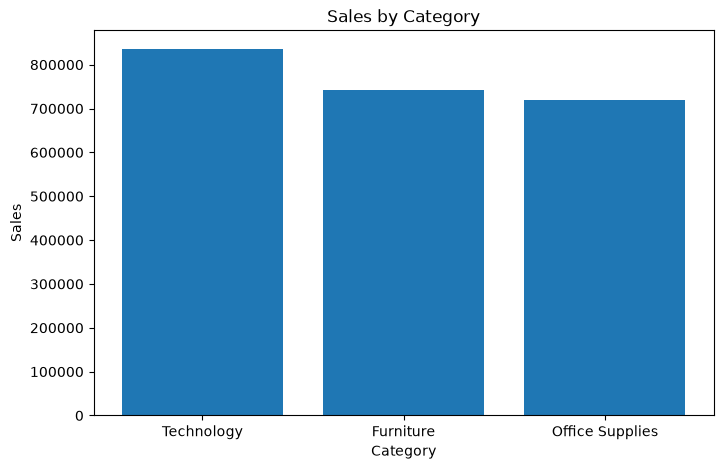

In [36]:
plot_df = category_summary.to_pandas()

plt.figure(figsize=(8,5))

plt.bar(
    plot_df["Category"],
    plot_df["Total_Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Cell 36 – Pie Chart

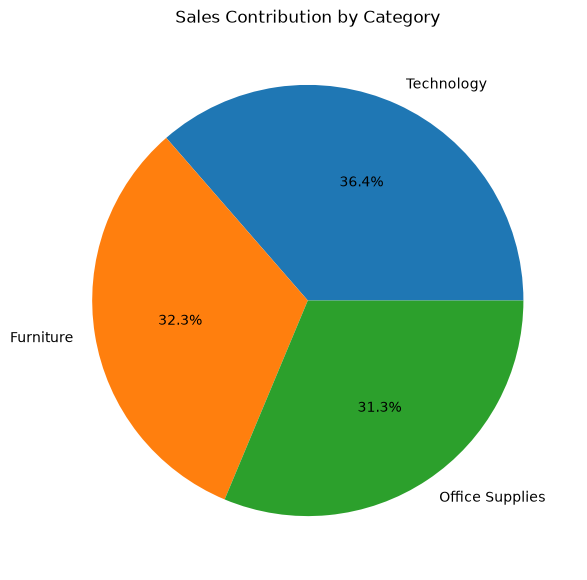

In [37]:
plt.figure(figsize=(7,7))

plt.pie(
    plot_df["Total_Sales"],
    labels=plot_df["Category"],
    autopct="%1.1f%%"
)

plt.title("Sales Contribution by Category")

plt.show()

Cell 37 – Histogram

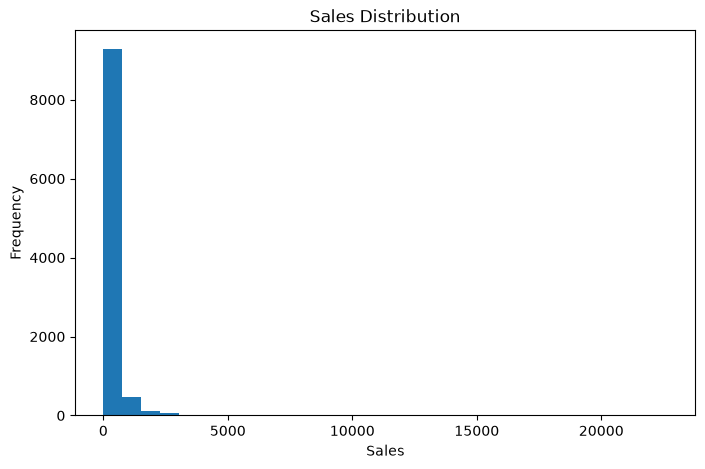

In [38]:
sales = df["Sales"].to_list()

plt.figure(figsize=(8,5))

plt.hist(sales, bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

Cell 38 – Line Chart

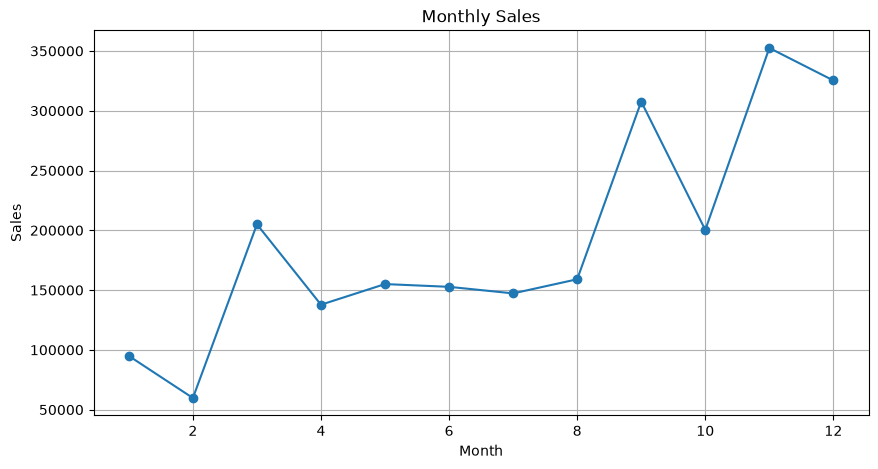

In [39]:
monthly = (
    df.group_by("Month")
    .agg(
        pl.sum("Sales").alias("Sales")
    )
    .sort("Month")
)

monthly_pd = monthly.to_pandas()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["Sales"],
    marker="o"
)

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid()

plt.show()

Cell 39 – Box Plot

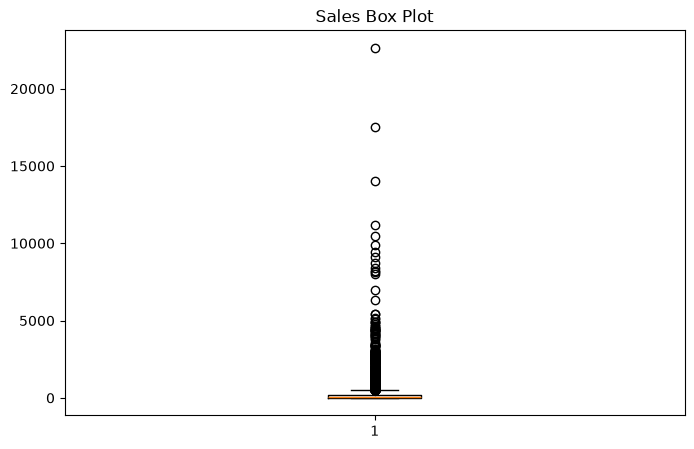

In [40]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"].to_list())

plt.title("Sales Box Plot")

plt.show()

Cell 40 – Top Customers

In [41]:
top_customers = (
    df.group_by("Customer_Name")
    .agg(
        pl.sum("Sales").alias("Total_Sales")
    )
    .sort("Total_Sales", descending=True)
    .head(10)
)

top_customers

Customer_Name,Total_Sales
str,f64
"""Sean Miller""",25043.05
"""Tamara Chand""",19052.218
"""Raymond Buch""",15117.339
"""Tom Ashbrook""",14595.62
"""Adrian Barton""",14473.571
"""Ken Lonsdale""",14175.229
"""Sanjit Chand""",14142.334
"""Hunter Lopez""",12873.298
"""Sanjit Engle""",12209.438


Cell 41 – Export Files

In [44]:
df.write_csv("cleaned_dataset.csv")

category_summary.write_csv("category_summary.csv")

region_summary.write_csv("region_summary.csv")

region_category_summary.write_csv("region_category_summary.csv")

pivot.write_csv("pivot_region_category.csv")

top_products.write_csv("top_products.csv")

Cell 42 – Business Insights

In [45]:
print("Business Insights")
print("-"*40)

print("1. Technology category contributes significantly to total sales.")
print("2. West region records strong overall sales performance.")
print("3. High discounts do not always result in higher profits.")
print("4. A small number of products generate a large share of revenue.")
print("5. Monthly sales trends reveal seasonal fluctuations.")
print("6. Some customers contribute much higher revenue than others.")
print("7. Furniture products may have lower profit margins despite good sales.")
print("8. Regional performance varies across product categories.")

Business Insights
----------------------------------------
1. Technology category contributes significantly to total sales.
2. West region records strong overall sales performance.
3. High discounts do not always result in higher profits.
4. A small number of products generate a large share of revenue.
5. Monthly sales trends reveal seasonal fluctuations.
6. Some customers contribute much higher revenue than others.
7. Furniture products may have lower profit margins despite good sales.
8. Regional performance varies across product categories.


Cell 43 – Conclusion

In [46]:
print("Conclusion")
print("-"*40)

print("The Superstore dataset was analyzed successfully using Polars.")
print("Data cleaning, filtering, aggregation, joins, pivot tables,")
print("feature engineering, visualizations, and exports were completed.")
print("The generated outputs provide valuable business insights and")
print("can be used for further analysis or predictive modeling.")

Conclusion
----------------------------------------
The Superstore dataset was analyzed successfully using Polars.
Data cleaning, filtering, aggregation, joins, pivot tables,
feature engineering, visualizations, and exports were completed.
The generated outputs provide valuable business insights and
can be used for further analysis or predictive modeling.
